In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel('ecommerce_cleaning_project_200.xlsx')
df

,Order_ID,Category,Product_Name,Price,Quantity,Rating,Payment_Method
0,1000,Electronics,Smartphone,1449.78,3,2.0,Direct Deposit
1,1001,Electronics,Laptop,453.92,2,1.7,Direct Deposit
2,1002,Sports,Running Shoes,783.72,1,3.8,PayPal
3,1003,Home & Kitchen,Air Fryer,1279.76,2,4.8,Direct Deposit
4,1004,Beauty,Lipstick,1355.04,5,1.5,Direct Deposit
...,...,...,...,...,...,...,...
200,1138,Home & Kitchen,Knife Set,229.45,1,3.0,Direct Deposit
201,1070,Home & Kitchen,Coffee Maker,336.97,4,2.8,Direct Deposit
202,1063,Beauty,Foundation,256.34,1,4.2,Direct Deposit
203,1134,Sports,Backpack,289.39,4,1.3,Direct Deposit


In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        205 non-null    int64  
 1   Category        205 non-null    object 
 2   Product_Name    205 non-null    object 
 3   Price           195 non-null    object 
 4   Quantity        205 non-null    int64  
 5   Rating          195 non-null    float64
 6   Payment_Method  195 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 11.3+ KB


In [6]:
df[df['Price'].isnull()]

,Order_ID,Category,Product_Name,Price,Quantity,Rating,Payment_Method
15,1015,Beauty,Face Cream,NaN,3,1.6,PayPal
30,1030,Electronics,Camera,NaN,3,5.0,Cash
45,1045,Clothing,T-Shirt,NaN,4,4.5,Cash
69,1069,Sports,Water Bottle,NaN,2,2.4,PayPal
95,1095,Beauty,Lipstick,NaN,4,2.9,PayPal
115,1115,Electronics,Laptop,NaN,1,3.2,Cash
128,1128,Clothing,Hoodie,NaN,5,2.7,Cash
158,1158,Electronics_Dept,Blender,NaN,4,3.1,Direct Deposit
170,1170,Clothing,T-Shirt,NaN,2,1.1,Cash
174,1174,Electronics,Laptop,NaN,3,4.7,Direct Deposit


In [7]:
df.isnull().sum()

Order_ID           0
Category           0
Product_Name       0
Price             10
Quantity           0
Rating            10
Payment_Method    10
dtype: int64

In [8]:
## Handling Price 
df['Price']=df['Price'].replace('FREE',0)
df['Price']=df['Price'].astype('float64')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\232123302.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Price']=df['Price'].replace('FREE',0)


<Axes: xlabel='Price', ylabel='Count'>

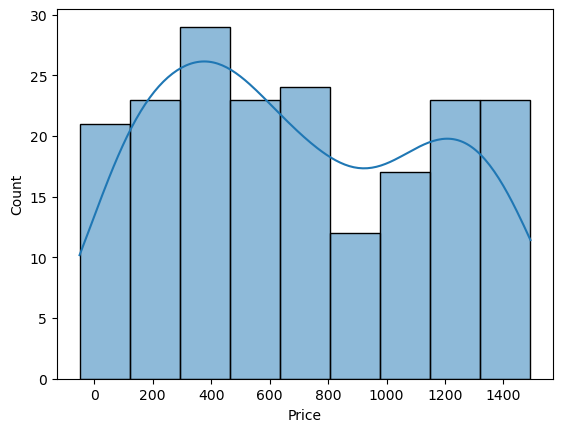

In [9]:
sns.histplot(df['Price'],kde=True)

In [10]:
df['Price']=df['Price'].fillna(df['Price'].mean())

In [11]:
df[df['Price'].isnull()]

,Order_ID,Category,Product_Name,Price,Quantity,Rating,Payment_Method


In [12]:
## Handling Rating 
df['Rating'].unique()


array([2. , 1.7, 3.8, 4.8, 1.5, 4.3, 1.4, 3.9, 2.5, 1.6, 1.2, 2.1, 1.1,
       3.4, 4.7, 3. , 3.5, 1.8, 1.3, 2.8, 9.5, 2.4, 4. , 5. , nan, 1. ,
       4.5, 2.9, 2.3, 4.9, 3.6, 2.6, 4.4, 4.2, 4.1, 3.7, 4.6, 3.1, 2.7,
       3.3, 1.9, 3.2, 2.2])

In [13]:
df['Rating']=df['Rating'].astype('float64')

<Axes: xlabel='Rating', ylabel='Count'>

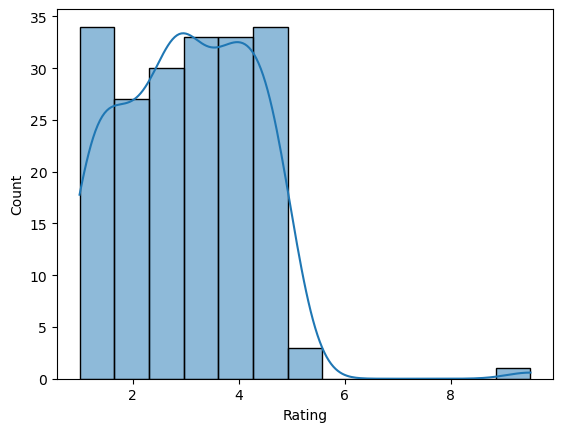

In [14]:
sns.histplot(df['Rating'],kde=True)

In [15]:
df['Rating']=df['Rating'].fillna(df['Rating'].median())


In [16]:
## Handling payment method 
df['Payment_Method']=df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])

In [17]:
df.isnull().sum()

Order_ID          0
Category          0
Product_Name      0
Price             0
Quantity          0
Rating            0
Payment_Method    0
dtype: int64

In [18]:
df['Category']=df['Category'].replace('electronics','Electronics')
df['Category']=df['Category'].replace('Electronics_Dept','Electronics')
df['Category'].unique()

array(['Electronics', 'Sports', 'Home & Kitchen', 'Beauty', 'Clothing'],
      dtype=object)

In [19]:
df.to_excel('cleaned2.xlsx')

In [20]:
print(df.info())
print("\n--- القيم المفقودة ---\n", df.isnull().sum())
print("\n--- إحصاءات التقييم ---\n", df['Rating'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        205 non-null    int64  
 1   Category        205 non-null    object 
 2   Product_Name    205 non-null    object 
 3   Price           205 non-null    float64
 4   Quantity        205 non-null    int64  
 5   Rating          205 non-null    float64
 6   Payment_Method  205 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 11.3+ KB
None

--- القيم المفقودة ---
 Order_ID          0
Category          0
Product_Name      0
Price             0
Quantity          0
Rating            0
Payment_Method    0
dtype: int64

--- إحصاءات التقييم ---
 count    205.000000
mean       3.043415
std        1.230741
min        1.000000
25%        2.100000
50%        3.000000
75%        3.900000
max        9.500000
Name: Rating, dtype: float64


In [21]:
df=df.drop_duplicates()

In [22]:
df['Total Revunue'] = df['Price']*df['Quantity']
df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\1971973624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Revunue'] = df['Price']*df['Quantity']


,Order_ID,Category,Product_Name,Price,Quantity,Rating,Payment_Method,Total Revunue
0,1000,Electronics,Smartphone,1449.78,3,2.0,Direct Deposit,4349.34
1,1001,Electronics,Laptop,453.92,2,1.7,Direct Deposit,907.84
2,1002,Sports,Running Shoes,783.72,1,3.8,PayPal,783.72
3,1003,Home & Kitchen,Air Fryer,1279.76,2,4.8,Direct Deposit,2559.52
4,1004,Beauty,Lipstick,1355.04,5,1.5,Direct Deposit,6775.20
...,...,...,...,...,...,...,...,...
195,1195,Beauty,Mascara,738.12,2,3.2,PayPal,1476.24
196,1196,Home & Kitchen,Toaster,588.31,1,2.5,PayPal,588.31
197,1197,Home & Kitchen,Rug,687.88,1,3.5,PayPal,687.88
198,1198,Electronics,Headphones,377.11,1,3.2,Cash,377.11


EDA

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\2352732599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Payment_Method',palette='viridis')


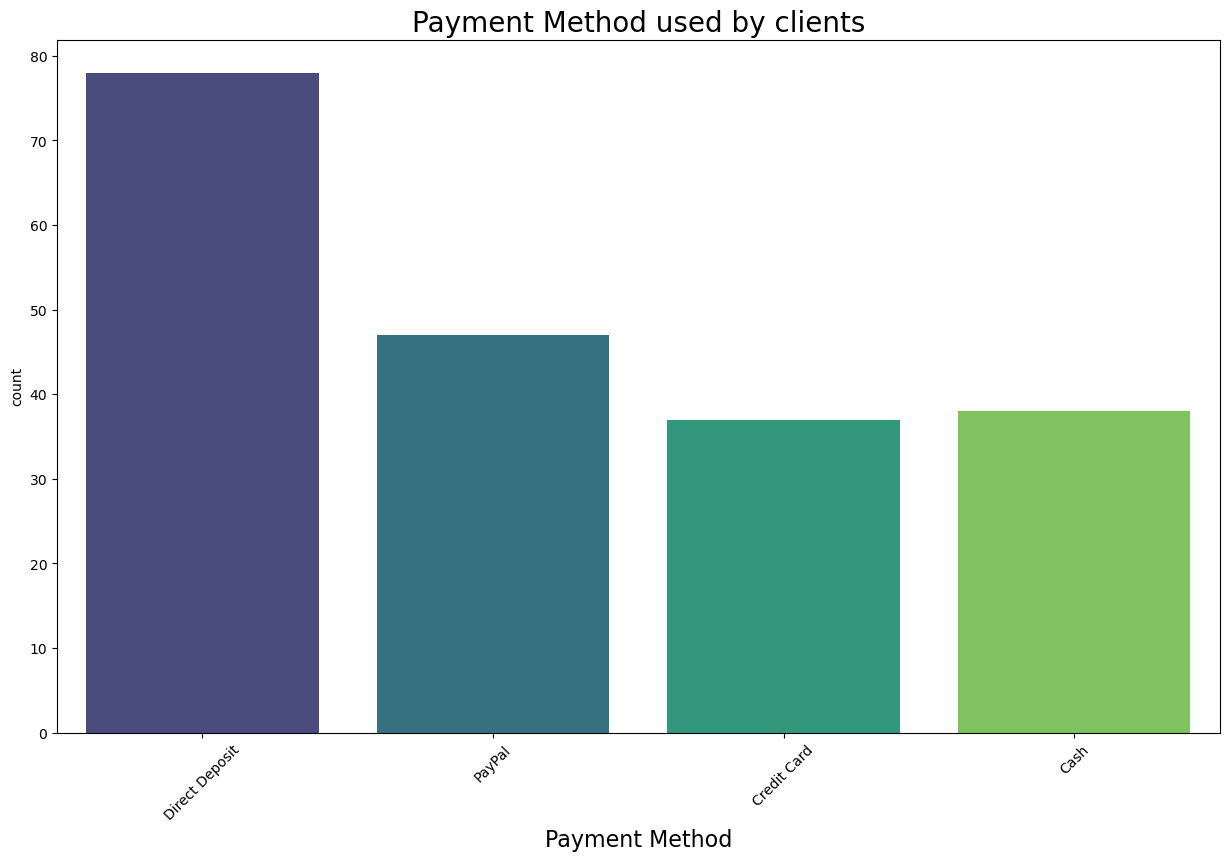

In [23]:
## wich Payment Mythod are most used
plt.figure(figsize=(15,9))
plt.title('Payment Method used by clients',fontsize=20)
sns.countplot(data=df,x='Payment_Method',palette='viridis')
plt.xlabel('Payment Method',fontsize=16)
plt.xticks(rotation=45)
plt.show()

The most of people use Direct Deposit with a percentage of 39% and the rest of payment method have percentage between 23.5% and 18.5% 

In [24]:
## Percentage of Direct Deposit
(df['Payment_Method']=='Direct Deposit').sum()*100/(len(df['Payment_Method']))


np.float64(39.0)

In [25]:
## Percentage of Paypal 
(df['Payment_Method']=='PayPal').sum()*100/(len(df['Payment_Method']))

np.float64(23.5)

In [26]:
## Percentage of Credit Card 
(df['Payment_Method']=='Credit Card').sum()*100/(len(df['Payment_Method']))

np.float64(18.5)

In [27]:
## Percentage of Cash

(df['Payment_Method']=='Cash').sum()*100/(len(df['Payment_Method']))

np.float64(19.0)

In [28]:
len(df['Payment_Method'])


200

([<matplotlib.patches.Wedge at 0x17a585fa120>,
 [Text(0.3726116893204676, 1.0349688541119233, 'Direct Diposit'),
  Text(-1.0987788569336545, -0.05181721292748108, 'PayPal'),
  Text(-0.2061190008813162, -1.0805160607208428, 'Cash'),
  Text(0.9193883481172169, -0.6039247182772828, 'Credit Card')],
 [Text(0.20324273962934594, 0.5645284658792308, '39.0%'),
  Text(-0.5993339219638114, -0.028263934324080586, '23.5%'),
  Text(-0.11242854593526337, -0.5893723967568233, '19.0%'),
  Text(0.5014845535184819, -0.3294134826966996, '18.5%')])

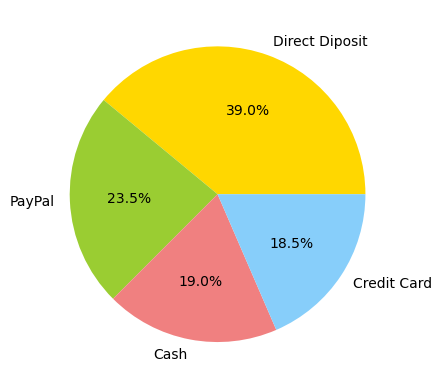

In [29]:
size=[39,23.5,19,18.5]
label=['Direct Diposit','PayPal','Cash','Credit Card']
colors = ['gold','yellowgreen','lightcoral','lightskyblue']

plt.pie(size,labels=label,colors=colors,autopct="%1.1f%%")

Since that 39% of clients use Direct diposit ,I suggest offering a discount for thos use Credit Card

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\1997273693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Category',palette='viridis')


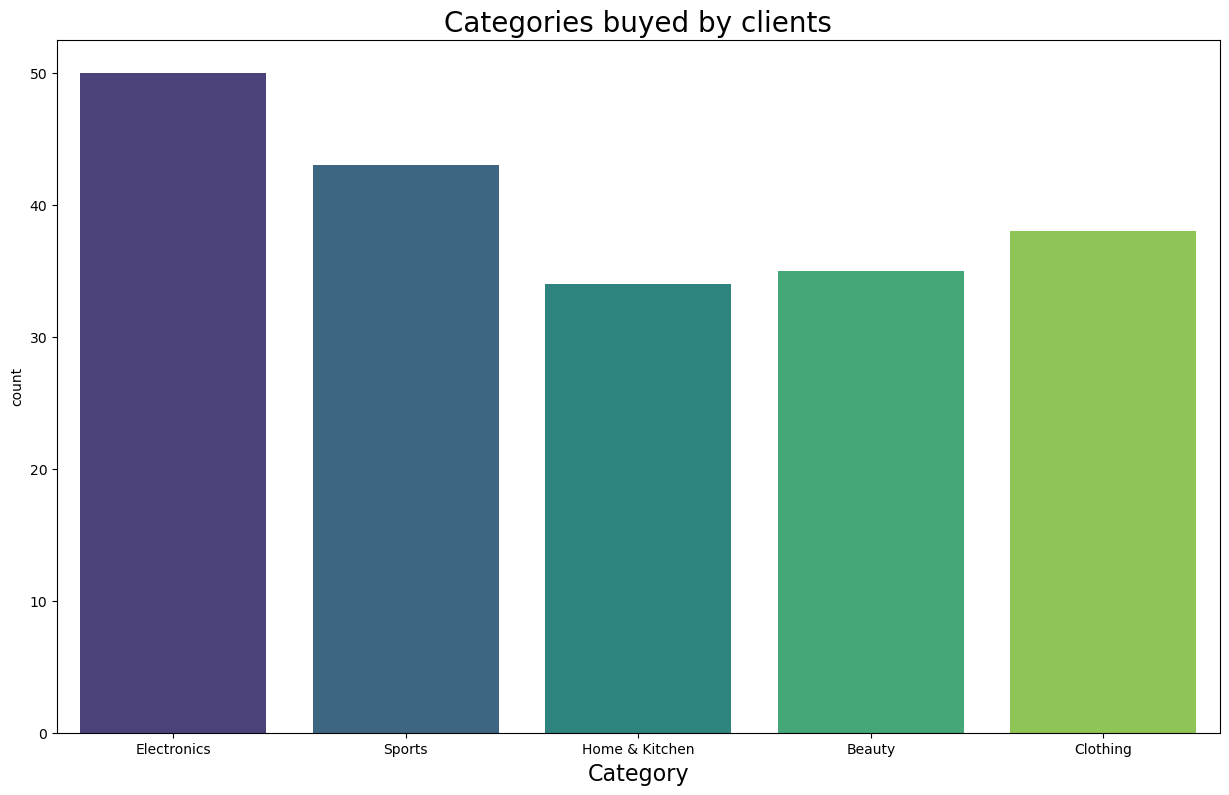

In [30]:
## wich category is more buyed 
plt.figure(figsize=(15,9))
plt.title('Categories buyed by clients',fontsize=20)
sns.countplot(data=df,x='Category',palette='viridis')
plt.xlabel('Category',fontsize=16)
plt.xticks(rotation=0)
plt.show()

Electronics and Sport Category has the moste prochas

In [31]:
## Wich category have more Financial returns
price_by_cat=df.groupby('Category')['Total Revunue'].sum()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\3382234405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_by_cat,palette='hls')


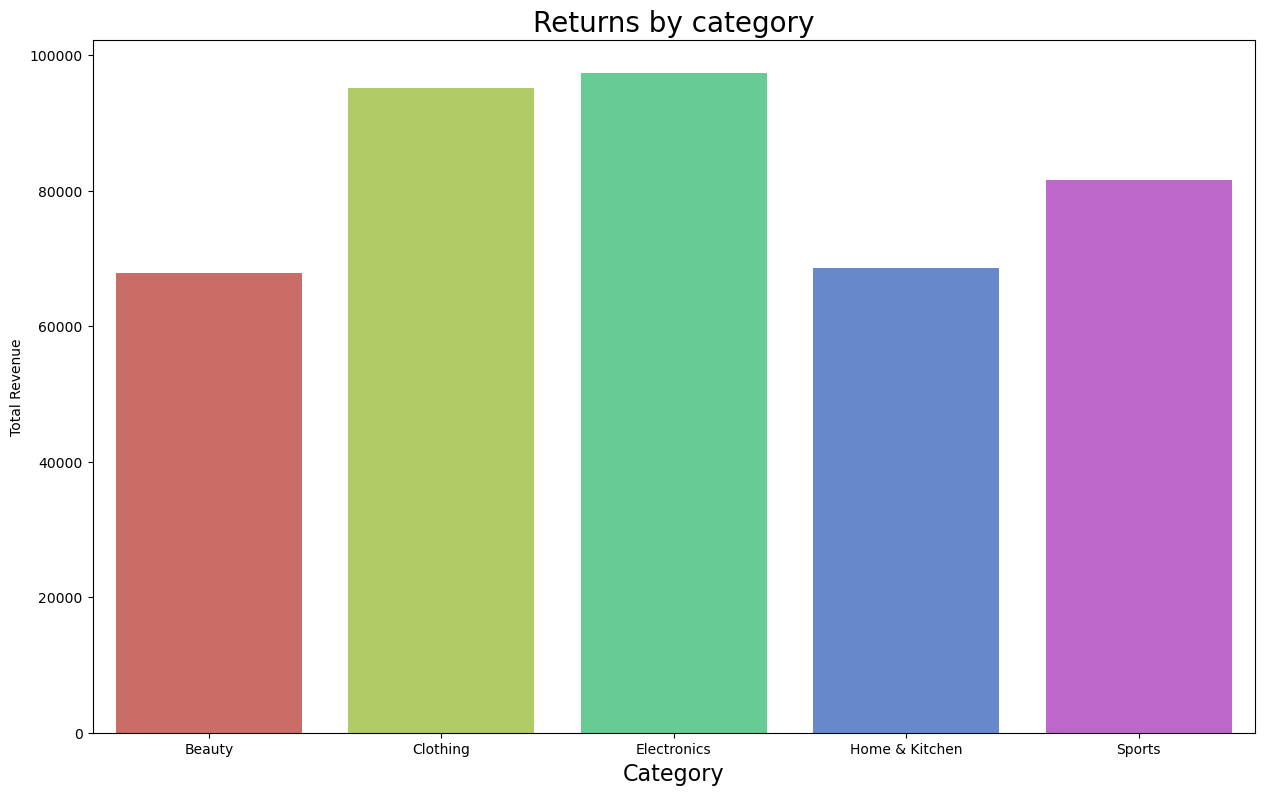

In [32]:
plt.figure(figsize=(15,9))
plt.title('Returns by category',fontsize=20)
sns.barplot(data=price_by_cat,palette='hls')
plt.xlabel('Category',fontsize=16)
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

1. Electronics and Clothing Categories have the most Total Revenue howver beauty and home&Kitchen have the less  
-----------------------------------------------------------------
I suggest that you to Focus more on Electronics and Clothing categories because they have large incomes, and offer limited discounts, such as one day a week, for beauty and home&Kitchen  categories.

"Note: These recommendations are based on Total Revenue. Profitability analysis was not performed due to the absence of 'Cost' data."

In [33]:
## Top 3 Products in Electronics Category 
electronics_df = df[df['Category'] == 'Electronics']
top_3_elec =electronics_df.groupby('Product_Name')['Total Revunue'].sum().nlargest(3)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\999610518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_3_elec,palette='hls')


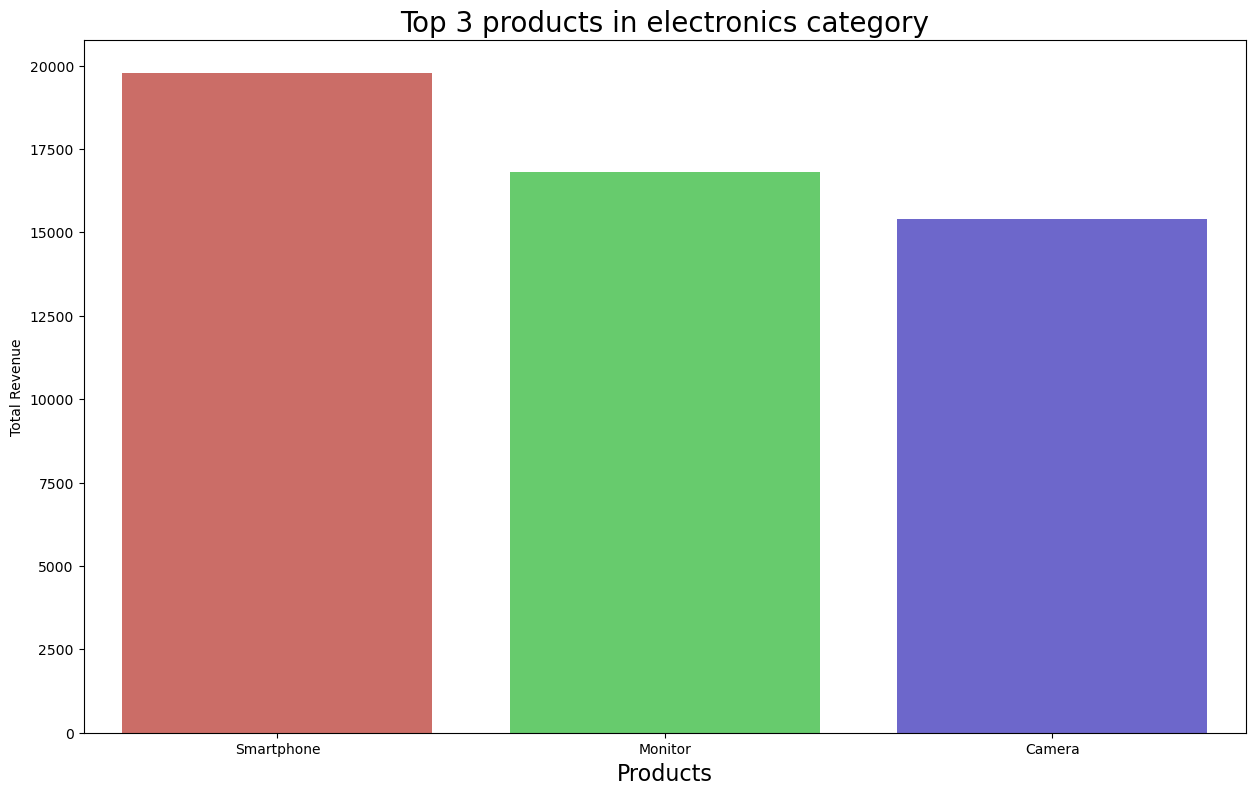

In [34]:
plt.figure(figsize=(15,9))
plt.title('Top 3 products in electronics category',fontsize=20)
sns.barplot(data=top_3_elec,palette='hls')
plt.xlabel('Products',fontsize=16)
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

the top 3 Products in Electronics Category are : Smartphone , Monitor and Camera 

In [35]:
electronics_df['Total Revunue'].sum()

np.float64(97377.12030769233)

In [36]:
df_top_3 = electronics_df[(electronics_df['Product_Name'] == 'Smartphone') | (electronics_df['Product_Name'] == 'Monitor')]
df_top_3['Total Revunue'].sum()

np.float64(36591.979999999996)

In [37]:
((df_top_3['Total Revunue'].sum())*100)/(electronics_df['Total Revunue'].sum())

np.float64(37.577595111024664)

We see that Only 3 products represent 37.6% of the Total Revunue of Electronics Category

<Axes: >

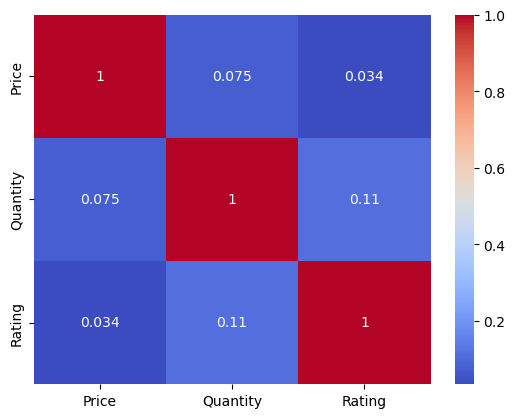

In [38]:
coor = df[['Price','Quantity','Rating']].corr()
sns.heatmap(coor,annot=True,cmap='coolwarm')

Insight: There is a weak to zero correlation between Price, Quantity, and Rating. This suggests that purchasing behavior is driven by factors other than price, such as brand loyalty or necessity.

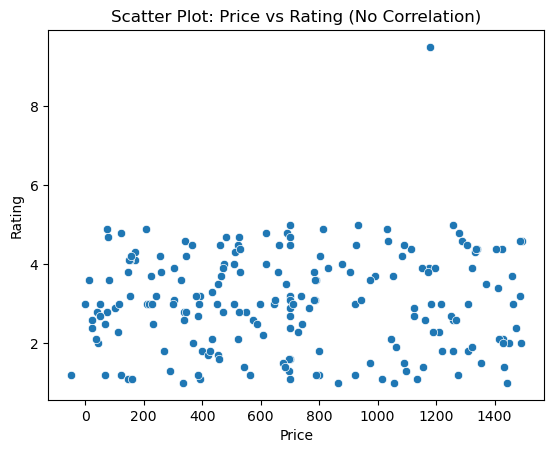

In [39]:
sns.scatterplot(data=df, x='Price', y='Rating')
plt.title('Scatter Plot: Price vs Rating (No Correlation)')
plt.show()

In [40]:
df['Rating'].mean()

np.float64(3.0445000000000007)

The average of rating is 3 that s mean the clients are Dissatisfied 

Proposed Solution: Implement a "Customer Feedback Loop." Since the data shows no correlation between price and rating, we should investigate service quality and shipping speed. I suggest prioritizing quality control for the top-selling electronics to raise the average rating from 3.0 to 7.0 within six months.

In [41]:
## The Rating of clients thoes pay with direct diposit 

bins = [0, 3, 5, 8, 10]
labels = ['Weak', 'Below Average', 'Good', 'Excellent']
df['Rating_Category'] = pd.cut(df['Rating'], bins=bins, labels=labels)
rating_counts = df['Rating_Category'].value_counts().reindex(labels)
print(rating_counts)

Rating_Category
Weak             107
Below Average     92
Good               0
Excellent          1
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\2177978356.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating_Category'] = pd.cut(df['Rating'], bins=bins, labels=labels)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9240\3667306203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating_Category', palette='RdYlGn') # من الأحمر للأخضر


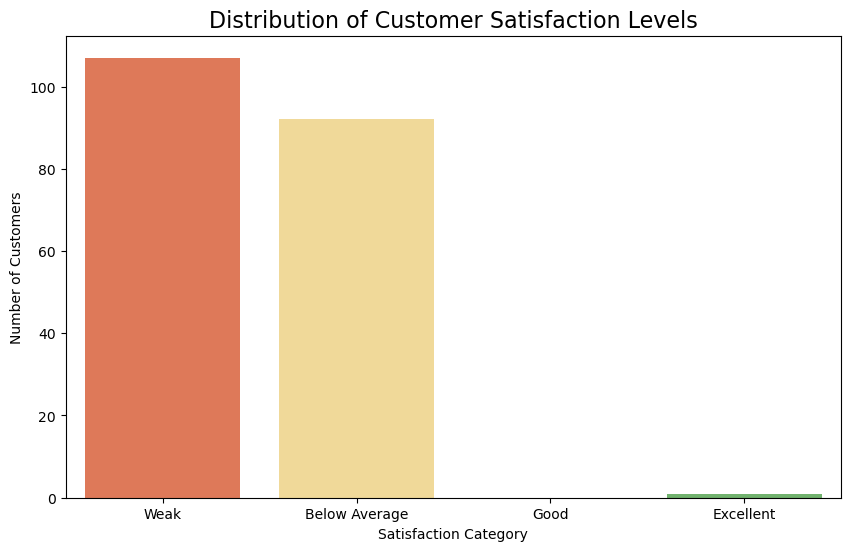

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Rating_Category', palette='RdYlGn') # من الأحمر للأخضر

plt.title('Distribution of Customer Satisfaction Levels', fontsize=16)
plt.xlabel('Satisfaction Category')
plt.ylabel('Number of Customers')
plt.show()

Strategic Insight: The most utilized payment method (Direct Deposit) is directly linked to poor customer reviews.
Action Plan: I strongly recommend optimizing the post-payment experience. Since "Retention is cheaper than Acquisition," focusing on service quality for these loyal

<Axes: >

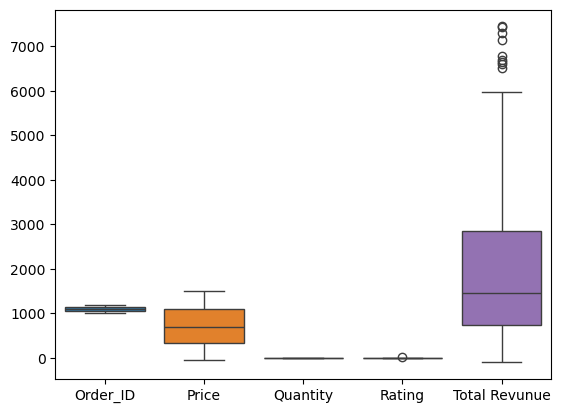

In [43]:
sns.boxplot(df)

I have identified a significant number of outliers in the Total Revenue. This is primarily driven by a customer trend toward purchasing high-ticket items, such as smartphones, which naturally carry a much higher price point compared to other product categories in the inventory."

In [44]:
from scipy import stats
## rating of direct deposit users 
groupe_a=df[df['Payment_Method']=='Direct Deposit']['Rating']
## rating of other payment method users 
groupe_b=df[df['Payment_Method']!='Direct Deposit']['Rating']

## T test 
t_stat , p_value = stats.ttest_ind(groupe_a,groupe_b)

## T and P Value 
print(f"T Statistic : {t_stat:.4f}")
print(f"P Statistic : {p_value:.4f}")

T Statistic : 0.3076
P Statistic : 0.7587


In [45]:
df.to_excel('clean_data.xlsx')

PermissionError: [Errno 13] Permission denied: 'clean_data.xlsx'

In [47]:
((electronics_df['Total Revunue'].sum())*100)/(df['Total Revunue'].sum())

np.float64(23.720319605938432)

In [ ]:
df['Rating'].mean()